In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy.stats as st
import matplotlib.colors as mcolors

matplotlib.rcParams['pdf.fonttype'] = 42



JAK2
TP53
ASXL1
TET2
NFE2
IDH2
DNMT3A
SRSF2
SH2B3
PPM1D
SignificanceResult(statistic=0.8629825921164745, pvalue=3.7346257006053103e-42)


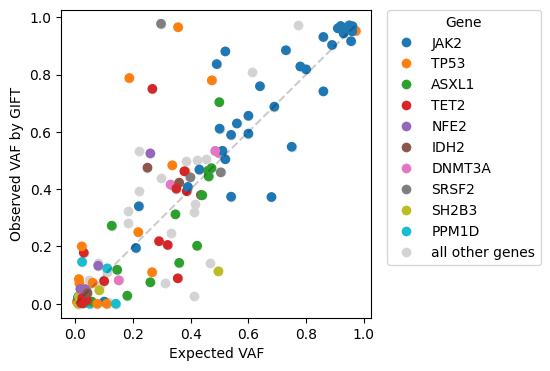

In [2]:
df = pd.read_csv('../output/all_MPNs_VAF_vs_expected_VAF.csv')
df['expected_frequency_from_bulk'] = df['expected_frequency_from_bulk'].fillna(0)

df['gene'] = df['HGVSc'].str.split(' ').str[0]
df['expected_frequency_from_bulk'] = df['expected_frequency_from_bulk'].fillna(0)
df = df.loc[df['expected_frequency_from_bulk'] != 0]

## plot frequency vs expected

fig,ax = plt.subplots(figsize=(4,4))

# Only include variants in legend that appear more than twice
variant_counts = df['gene'].value_counts()
variants_to_show = variant_counts[variant_counts > 3].index

# Get a more comprehensive list of colors by combining multiple color palettes
hex_colors = (list(mcolors.TABLEAU_COLORS.values()) + 
              list(mcolors.BASE_COLORS.values())[4:])

x = df['expected_frequency_from_bulk']
y = df['frequency']

# Assign a random color to each unique gene
unique_names = df['gene'].unique()
# Map variants_to_show to hex_colors, all others to grey
color_map = {name: 'lightgrey' for name in unique_names}
for name, color in zip(variants_to_show, hex_colors):
    print(name)
    color_map[name] = color
colors = df['gene'].map(color_map)

# Plot all variants in light grey as background
ax.scatter(x, y, c='lightgrey')

# Plot variants_to_show on top with assigned colors and alpha
mask = df['gene'].isin(variants_to_show)
ax.scatter(x[mask], y[mask], c=colors[mask])

# Create a legend mapping colors to names
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label=name,
               markerfacecolor=color_map[name], markersize=8)
    for name in variants_to_show
]
# Add a lightgrey marker for "all other variants"
handles.append(
    plt.Line2D([0], [0], marker='o', color='w', label='all other genes',
               markerfacecolor='lightgrey', markersize=8)
)

ax.legend(handles=handles, title="Gene", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax.set_xlabel('Expected VAF')
ax.set_ylabel('Observed VAF by GIFT')

# Add y=x reference line
min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.2, label='y=x')
print(st.spearmanr(x, y))

plt.savefig('../plots/gapfill_frequency_vs_expected_frequency.pdf', bbox_inches='tight')